
Found experiments:
   Flat XLMR
   Gold_routing
   Hard_routing
   Parent Shared Expert
   Parent_Conditioned_Hierarchica
   shared_multiCore_XLM-R_diffWeightsBoth


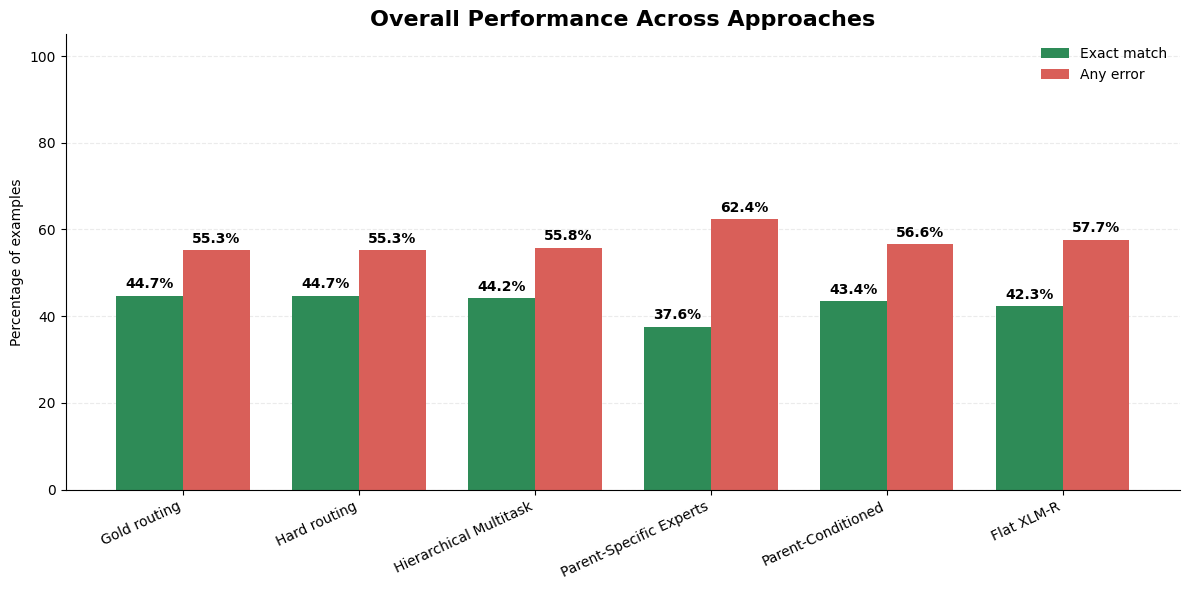


Saved: C:\Users\alrazz\Downloads\comparison_plots\overall_performance.png


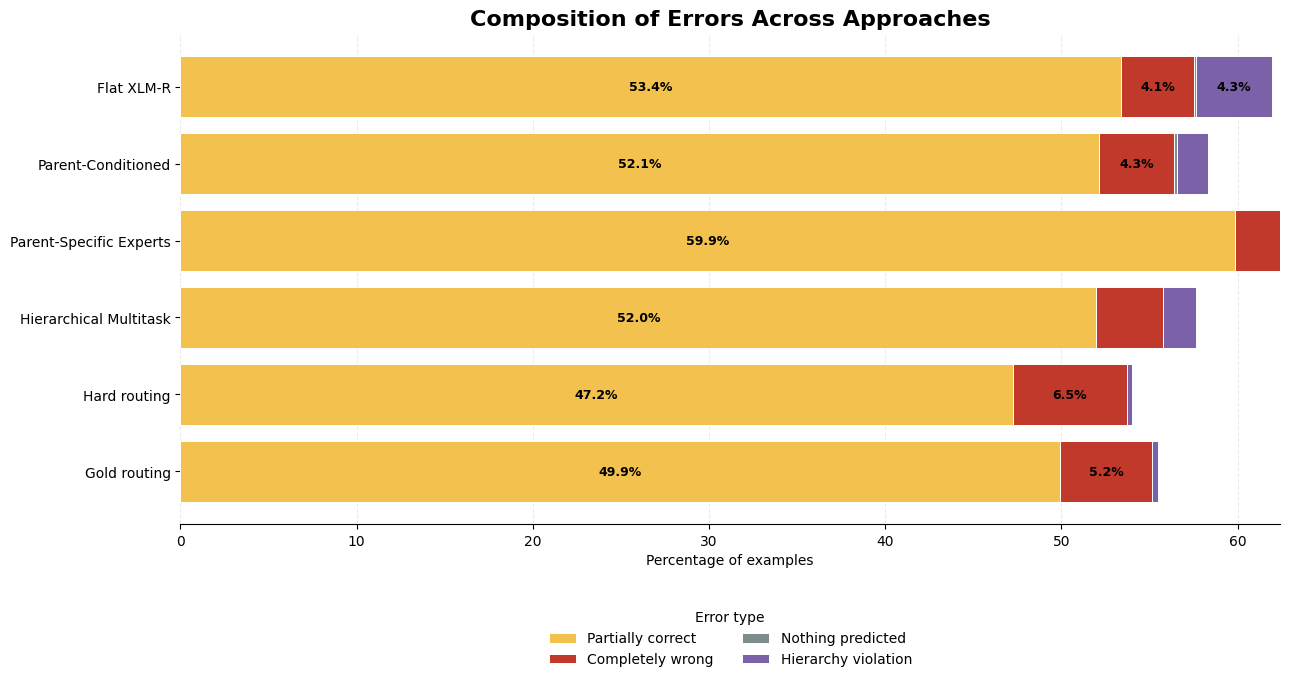

Saved: C:\Users\alrazz\Downloads\comparison_plots\error_composition.png


================ SUMMARY ================

category                 exact_match  any_error  partially_correct  completely_wrong  nothing_predicted  hierarchy_violation
Gold routing                   44.71      55.29              49.92              5.21               0.00                 0.32
Hard routing                   44.71      55.29              47.24              6.48               0.00                 0.32
Hierarchical Multitask         44.23      55.77              51.97              3.79               0.00                 1.90
Parent-Specific Experts        37.60      62.40              59.87              2.53               0.00                 0.00
Parent-Conditioned             43.44      56.56              52.13              4.27               0.16                 1.74
Flat XLM-R                     42.34      57.66              53.40              4.11               0.16                 4.27




In [2]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


# ============================================================
# SETTINGS
# ============================================================

ROOT = Path(r"C:\Users\alrazz\Downloads")

CSV_NAME = "per_label_tuned_document_summary.csv"
SUBFOLDER = "hierarchical_error_analysis"

OUTPUT_DIR = ROOT / "comparison_plots"
OUTPUT_DIR.mkdir(exist_ok=True)


# ============================================================
# Find all experiments
# ============================================================

csv_files = list(ROOT.glob(f"*/{SUBFOLDER}/{CSV_NAME}"))

if not csv_files:
    raise FileNotFoundError(
        f"No files found matching:\n"
        f"{ROOT}\\*\\{SUBFOLDER}\\{CSV_NAME}"
    )


print("\nFound experiments:")
for f in csv_files:
    print("  ", f.parent.parent.name)


# ============================================================
# Read all experiments
# ============================================================

experiments = {}

for csv_file in csv_files:

    experiment_name = csv_file.parent.parent.name

    df = pd.read_csv(csv_file)

    required = {"category", "count", "percentage"}

    missing = required - set(df.columns)

    if missing:
        print(
            f"\nWARNING: {experiment_name} is missing "
            f"columns: {missing}"
        )
        continue

    experiments[experiment_name] = df


if not experiments:
    raise ValueError("No valid experiment files found.")


# ============================================================
# Convert to one table
# ============================================================

all_data = []

for experiment_name, df in experiments.items():

    temp = df.copy()
    temp["experiment"] = experiment_name

    all_data.append(temp)


data = pd.concat(all_data, ignore_index=True)


# ============================================================
# Create experiment x category table
# ============================================================

pivot = data.pivot_table(
    index="experiment",
    columns="category",
    values="percentage",
    aggfunc="sum",
    fill_value=0
)


# ============================================================
# Category names
# ============================================================

category_names = {
    "exact_match": "Exact match",
    "any_error": "Any error",
    "partially_correct": "Partially correct",
    "completely_wrong": "Completely wrong",
    "nothing_predicted": "Nothing predicted",
    "hierarchy_violation": "Hierarchy violation",
}


# ============================================================
# Desired experiment order
# ============================================================

preferred_order = [
    "Gold_routing",
    "Hard_routing",
    "shared_multiCore_XLM-R_diffWeightsBoth",
    "Parent Shared Expert",
    "Parent_Conditioned_Hierarchica",
    "Flat XLMR",
]


# Keep only experiments that actually exist
ordered_experiments = [
    x for x in preferred_order
    if x in pivot.index
]


# Add any unexpected experiments
ordered_experiments += [
    x for x in pivot.index
    if x not in ordered_experiments
]


pivot = pivot.reindex(ordered_experiments)


# ============================================================
# Shorter display names
# ============================================================

display_experiment_names = {
    "Gold_routing": "Gold routing",
    "Hard_routing": "Hard routing",
    "shared_multiCore_XLM-R_diffWeightsBoth": "Hierarchical Multitask",
    "Parent Shared Expert": "Parent-Specific Experts",
    "Parent_Conditioned_Hierarchica": "Parent-Conditioned",
    "Flat XLMR": "Flat XLM-R",
}


display_names = [
    display_experiment_names.get(
        x,
        x
    )
    for x in pivot.index
]


# ============================================================
# Colors
# ============================================================

COLORS = {
    "exact_match": "#2E8B57",
    "any_error": "#D95F59",

    "partially_correct": "#F2C14E",
    "completely_wrong": "#C0392B",
    "nothing_predicted": "#7F8C8D",
    "hierarchy_violation": "#7B61A8",
}


# ============================================================
# Plot 1:
# Exact match vs Any error
# ============================================================

fig, ax = plt.subplots(
    figsize=(12, 6)
)

x = np.arange(len(pivot))
width = 0.38


exact = pivot["exact_match"].values
errors = pivot["any_error"].values


bars1 = ax.bar(
    x - width / 2,
    exact,
    width,
    label="Exact match",
    color=COLORS["exact_match"]
)

bars2 = ax.bar(
    x + width / 2,
    errors,
    width,
    label="Any error",
    color=COLORS["any_error"]
)


# Add percentage labels
for bars in [bars1, bars2]:

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 1,
            f"{height:.1f}%",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )


ax.set_xticks(x)
ax.set_xticklabels(
    display_names,
    rotation=25,
    ha="right"
)

ax.set_ylabel("Percentage of examples")

ax.set_ylim(0, 105)

ax.set_title(
    "Overall Performance Across Approaches",
    fontsize=16,
    fontweight="bold"
)

ax.legend(
    frameon=False,
    loc="upper right"
)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

output1 = OUTPUT_DIR / "overall_performance.png"

plt.savefig(
    output1,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"\nSaved: {output1}")


# ============================================================
# Plot 2:
# Error composition
# ============================================================

error_categories = [
    "partially_correct",
    "completely_wrong",
    "nothing_predicted",
    "hierarchy_violation",
]

available_error_categories = [
    c for c in error_categories
    if c in pivot.columns
]


fig, ax = plt.subplots(
    figsize=(13, 7)
)


left = np.zeros(len(pivot))


for category in available_error_categories:

    values = pivot[category].values

    bars = ax.barh(
        display_names,
        values,
        left=left,
        label=category_names[category],
        color=COLORS[category],
        edgecolor="white",
        linewidth=0.7
    )

    # Percentage labels
    for i, value in enumerate(values):

        if value >= 4:

            ax.text(
                left[i] + value / 2,
                i,
                f"{value:.1f}%",
                ha="center",
                va="center",
                fontsize=9,
                fontweight="bold"
            )

    left += values


ax.set_xlabel(
    "Percentage of examples"
)

ax.set_title(
    "Composition of Errors Across Approaches",
    fontsize=16,
    fontweight="bold"
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.25
)

ax.set_axisbelow(True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

ax.legend(
    title="Error type",
    bbox_to_anchor=(0.5, -0.15),
    loc="upper center",
    ncol=2,
    frameon=False
)

plt.tight_layout()

output2 = OUTPUT_DIR / "error_composition.png"

plt.savefig(
    output2,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Saved: {output2}")


# ============================================================
# Print a useful summary table
# ============================================================

print("\n\n================ SUMMARY ================\n")

summary_columns = [
    c for c in [
        "exact_match",
        "any_error",
        "partially_correct",
        "completely_wrong",
        "nothing_predicted",
        "hierarchy_violation",
    ]
    if c in pivot.columns
]

summary = pivot[summary_columns].copy()

summary.index = display_names

summary = summary.round(2)

print(summary.to_string())

print("\n=========================================\n")
